<a href="https://colab.research.google.com/github/pratikshasurya432-tech/Pharma-Drug-Sales-Analysis---Demand-Forecasting/blob/main/Pharma_Demand_Forecasting_%26_Supply_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pharma Demand Forecasting & Supply Optimization

In [ ]:
# Import Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score



In [ ]:
## Data Collection

In [ ]:
salesdataset = pd.read_csv("/salesdaily_CLEANED DATA (1).csv")

In [ ]:
print(salesdataset.head())

        datum  Anti-inflammatory and anti-rheumatic products  \
0  01-02-2014                                            0.0   
1  01-03-2014                                            8.0   
2  01-04-2014                                            2.0   
3  01-05-2014                                            4.0   
4  01-06-2014                                            5.0   

   Anti-inflammatory medicines  Pain relief medicines  Anilides  \
0                         3.67                    3.4     32.40   
1                         4.00                    4.4     50.60   
2                         1.00                    6.5     61.85   
3                         3.00                    7.0     41.10   
4                         1.00                    4.5     21.70   

   Anxiolytic medicines  Hypnotics and sedatives  \
0                   7.0                      0.0   
1                  16.0                      0.0   
2                  10.0                      0.0   
3   

In [ ]:
print(salesdataset.shape)

(2106, 13)


In [ ]:
print(salesdataset.columns)

Index(['datum', 'Anti-inflammatory and anti-rheumatic products',
       'Anti-inflammatory medicines', 'Pain relief medicines', 'Anilides',
       'Anxiolytic medicines', 'Hypnotics and sedatives',
       'Asthma/respiratory medicines', 'Allergy medicines', 'Year', 'Month',
       'Hour', 'Weekday Name'],
      dtype='object')


In [ ]:
# Dataset information

In [ ]:
print(salesdataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   datum                                          2106 non-null   object 
 1   Anti-inflammatory and anti-rheumatic products  2106 non-null   float64
 2   Anti-inflammatory medicines                    2106 non-null   float64
 3   Pain relief medicines                          2106 non-null   float64
 4   Anilides                                       2106 non-null   float64
 5   Anxiolytic medicines                           2106 non-null   float64
 6   Hypnotics and sedatives                        2106 non-null   float64
 7   Asthma/respiratory medicines                   2106 non-null   float64
 8   Allergy medicines                              2106 non-null   float64
 9   Year                                           2106 

In [ ]:
salesdataset['datum'] = pd.to_datetime(salesdataset['datum'], format='mixed', dayfirst=False)

In [ ]:
print(salesdataset.head())

       datum  Anti-inflammatory and anti-rheumatic products  \
0 2014-01-02                                            0.0   
1 2014-01-03                                            8.0   
2 2014-01-04                                            2.0   
3 2014-01-05                                            4.0   
4 2014-01-06                                            5.0   

   Anti-inflammatory medicines  Pain relief medicines  Anilides  \
0                         3.67                    3.4     32.40   
1                         4.00                    4.4     50.60   
2                         1.00                    6.5     61.85   
3                         3.00                    7.0     41.10   
4                         1.00                    4.5     21.70   

   Anxiolytic medicines  Hypnotics and sedatives  \
0                   7.0                      0.0   
1                  16.0                      0.0   
2                  10.0                      0.0   
3         

In [ ]:
# Checking the number of missing values

In [ ]:
print(salesdataset.isnull().sum())

datum                                            0
Anti-inflammatory and anti-rheumatic products    0
Anti-inflammatory medicines                      0
Pain relief medicines                            0
Anilides                                         0
Anxiolytic medicines                             0
Hypnotics and sedatives                          0
Asthma/respiratory medicines                     0
Allergy medicines                                0
Year                                             0
Month                                            0
Hour                                             0
Weekday Name                                     0
dtype: int64


In [ ]:
salesdataset = salesdataset.fillna(0)

In [ ]:
salesdataset = salesdataset.dropna()

In [ ]:
salesdataset= salesdataset.drop_duplicates()

In [ ]:
print(salesdataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   datum                                          2106 non-null   datetime64[ns]
 1   Anti-inflammatory and anti-rheumatic products  2106 non-null   float64       
 2   Anti-inflammatory medicines                    2106 non-null   float64       
 3   Pain relief medicines                          2106 non-null   float64       
 4   Anilides                                       2106 non-null   float64       
 5   Anxiolytic medicines                           2106 non-null   float64       
 6   Hypnotics and sedatives                        2106 non-null   float64       
 7   Asthma/respiratory medicines                   2106 non-null   float64       
 8   Allergy medicines                              2106 non-nu

EDA (Exploratory Data Analysis)

In [ ]:
# Statistical measures of the data

In [ ]:
print(salesdataset.describe())

                               datum  \
count                           2106   
mean   2016-11-19 12:00:00.000000256   
min              2014-01-02 00:00:00   
25%              2015-06-12 06:00:00   
50%              2016-11-19 12:00:00   
75%              2018-04-29 18:00:00   
max              2019-10-08 00:00:00   
std                              NaN   

       Anti-inflammatory and anti-rheumatic products  \
count                                    2106.000000   
mean                                        5.033683   
min                                         0.000000   
25%                                         3.000000   
50%                                         4.990000   
75%                                         6.670000   
max                                        17.340000   
std                                         2.737579   

       Anti-inflammatory medicines  Pain relief medicines     Anilides  \
count                  2106.000000            2106.000000  2

In [ ]:
print(salesdataset.corr(numeric_only=True))

                                               Anti-inflammatory and anti-rheumatic products  \
Anti-inflammatory and anti-rheumatic products                                       1.000000   
Anti-inflammatory medicines                                                         0.189982   
Pain relief medicines                                                               0.147483   
Anilides                                                                            0.179634   
Anxiolytic medicines                                                                0.030208   
Hypnotics and sedatives                                                             0.015622   
Asthma/respiratory medicines                                                        0.082835   
Allergy medicines                                                                   0.088195   
Year                                                                                0.096797   
Month                                   

Sales Distribution

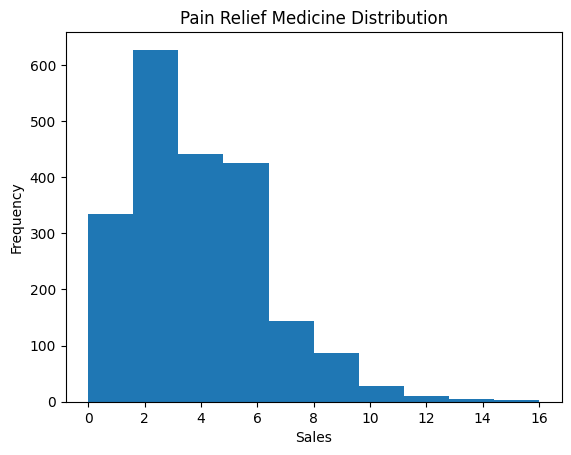

In [ ]:
import matplotlib.pyplot as plt

salesdataset['Pain relief medicines'].hist()

plt.title("Pain Relief Medicine Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

Daily Sales Trend

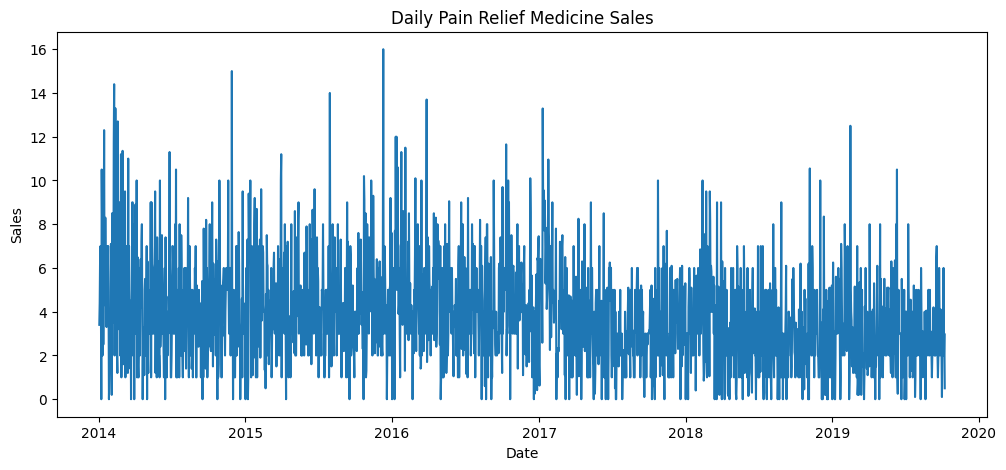

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(salesdataset['datum'], salesdataset['Pain relief medicines'])

plt.title("Daily Pain Relief Medicine Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(False)
plt.show()

Correlation Heatmap

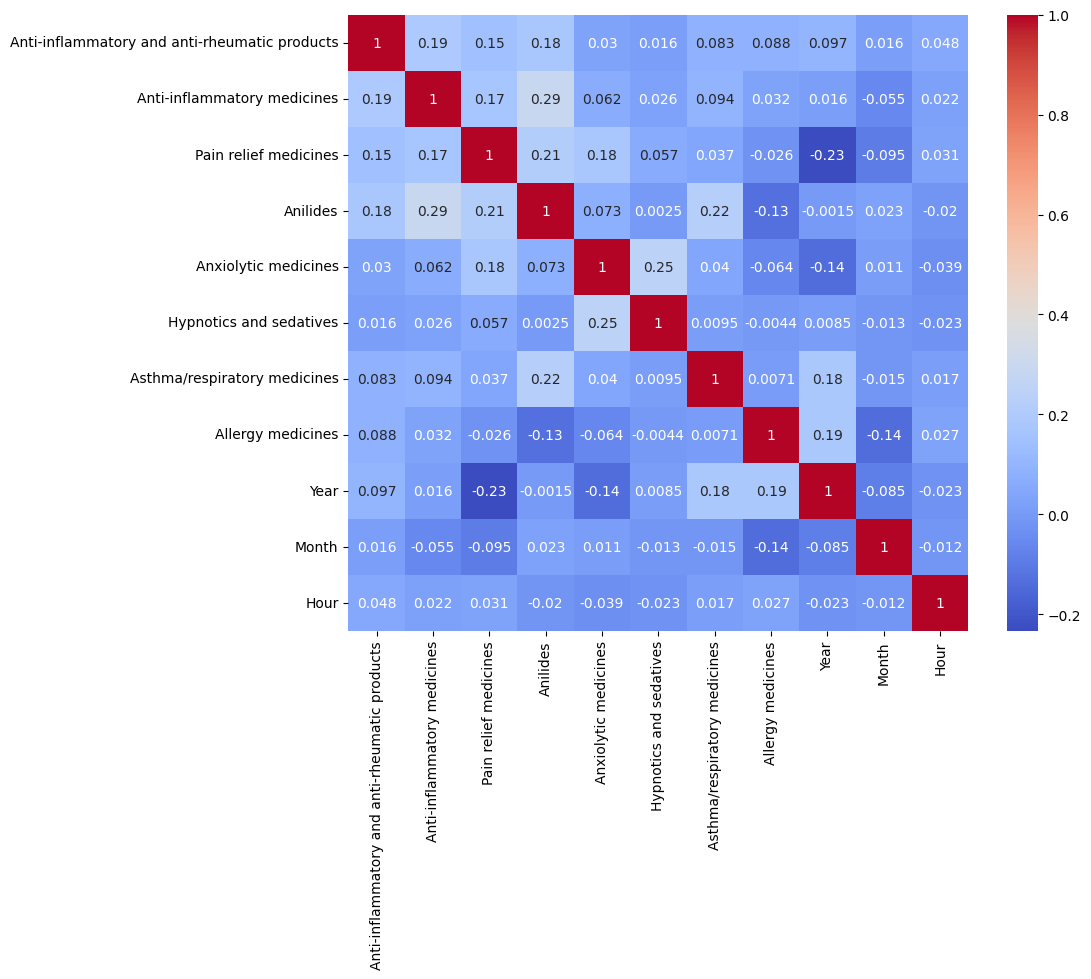

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    salesdataset.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Dark color = strong relationship
Light color = weak relationship

If:
Pain relief medicines highly correlate with allergy medicines,
then those features help prediction.

##FEATURE ENGINEERING

Extract Date Features

In [ ]:
salesdataset['year'] = salesdataset['datum'].dt.year
salesdataset['month'] = salesdataset['datum'].dt.month
salesdataset['day'] = salesdataset['datum'].dt.day
salesdataset['weekday'] = salesdataset['datum'].dt.weekday

Create Lag Features

Yesterday Sales

In [ ]:
salesdataset['lag_1'] = salesdataset['Pain relief medicines'].shift(1)

Previous Week Sales

In [ ]:
salesdataset['lag_7'] = salesdataset['Pain relief medicines'].shift(7)

In [ ]:
print(salesdataset['lag_7'])

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
2101    4.0
2102    4.1
2103    3.0
2104    2.1
2105    0.1
Name: lag_7, Length: 2106, dtype: float64


Rolling Average

In [ ]:
salesdataset['rolling_mean_7'] = (
    salesdataset['Pain relief medicines']
    .rolling(window=7)
    .mean()
)

In [ ]:
print(salesdataset)

          datum  Anti-inflammatory and anti-rheumatic products  \
0    2014-01-02                                           0.00   
1    2014-01-03                                           8.00   
2    2014-01-04                                           2.00   
3    2014-01-05                                           4.00   
4    2014-01-06                                           5.00   
...         ...                                            ...   
2101 2019-10-04                                           7.34   
2102 2019-10-05                                           3.84   
2103 2019-10-06                                           4.00   
2104 2019-10-07                                           7.34   
2105 2019-10-08                                           0.33   

      Anti-inflammatory medicines  Pain relief medicines  Anilides  \
0                           3.670                   3.40     32.40   
1                           4.000                   4.40     50.60 

Remove Nulls Created by Lag

In [ ]:
salesdataset = salesdataset.dropna()

In [ ]:
## TRAIN TEST SPLIT

In [ ]:
X = salesdataset.drop(
    ['Pain relief medicines', 'datum'], axis=1)
y = salesdataset['Pain relief medicines']

In [ ]:
print(X)

      Anti-inflammatory and anti-rheumatic products  \
7                                              7.00   
8                                              5.00   
9                                              5.00   
10                                             2.00   
11                                             7.34   
...                                             ...   
2101                                           7.34   
2102                                           3.84   
2103                                           4.00   
2104                                           7.34   
2105                                           0.33   

      Anti-inflammatory medicines  Anilides  Anxiolytic medicines  \
7                           1.680     25.00                  16.0   
8                           2.000     53.30                  15.0   
9                           4.340     52.30                  14.0   
10                          0.660     12.00                   8

Split data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

XGBOOST MODEL

In [ ]:
from xgboost import XGBRegressor


In [ ]:
X_train['Weekday Name'] = X_train['Weekday Name'].astype('category')
X_test['Weekday Name'] = X_test['Weekday Name'].astype('category')

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    enable_categorical=True
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Evaluation

Prediction on training data

In [ ]:
# accuracy for prediction on training data

In [ ]:
training_data_prediction = model.predict(X_train)

In [ ]:
print(training_data_prediction)

[1.3079525 3.489717  5.1145535 ... 6.9958673 3.9477274 4.720168 ]


In [ ]:
# R squared error

In [ ]:
score_1 = metrics.r2_score(y_train, training_data_prediction)

In [ ]:
# Mean absolute Error

In [ ]:
score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)

In [ ]:
print("R squared error : ", score_1)
print("Mean absolute Error : ", score_2)

R squared error :  0.7636688636782005
Mean absolute Error :  0.8897399498070606


Prediction on test data

In [ ]:
# accuracy for prediction on training data

In [ ]:
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[ 4.39445     2.943544    5.3078933   6.157211    4.2609887   3.0670657
  2.4563842   4.5144224   3.6139655   3.88693     1.329281    3.183565
  5.684004    4.3702097   4.1210694   4.424619    6.070346    4.7793617
  4.585316    3.3585265   2.738736    4.8385386   3.2460387   3.6345625
  3.5798333   3.2742357   3.3898132   5.6311526   1.2967354   5.0468826
  5.09037     4.6985774   1.618484    3.8926222   7.460838    4.794119
  4.2541986   2.2313712   4.000343    3.3216329   2.5974536   4.984498
  4.2936163   3.5876298   3.5724537   3.1134048   4.283346    5.560789
  4.9984      4.863646    3.3187904   4.4762683   4.175382    1.6207054
  3.6116607   3.582172    3.5693996   4.272047    3.489012    2.780822
  3.5504365   6.7169604   3.4350977   3.6709304   1.2212604   4.373236
  2.877512    2.8219502   3.12844     3.2451422   2.6860702   4.456493
  4.697282    6.09872     4.1028547   3.2078426   5.108936    4.6417055
  3.8908372   3.2370737   3.6501992   3.4619637   4.0813384   3.6942751

In [ ]:
# R squared error

In [ ]:
score_1 = metrics.r2_score(y_test, test_data_prediction)

In [ ]:
# Mean absolute Error

In [ ]:
score_2 = metrics.mean_absolute_error(y_test, test_data_prediction)

In [ ]:
print("R squared error : ", score_1)
print("Mean absolute Error : ", score_2)

R squared error :  0.28330194756478466
Mean absolute Error :  1.5710689509336122


PREDICTION

In [ ]:
y_pred = model.predict(X_test)

VISUALIZATION

Actual vs Predicted

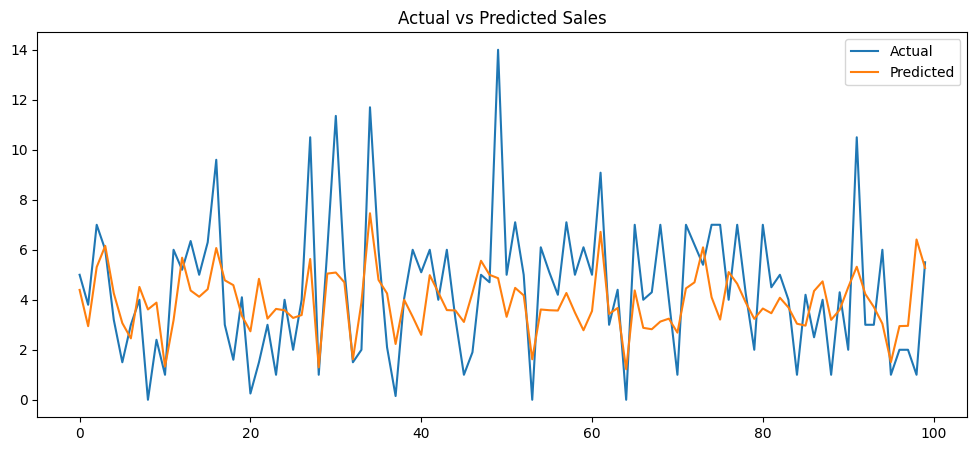

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    y_test.values[:100],
    label='Actual')
plt.plot(
    y_pred[:100],
    label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()